# InceptionV3 Benchmark

In [1]:
model_name = "InceptionV3"

import torch
from torch import nn
from torchvision import models
import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

/root/anaconda3/envs/iree/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare

In [2]:
MAGIC_NUM = 7777e-5

model = models.inception_v3(pretrained=False).train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = torch.compile(model, backend="inductor")

recompute, storeall = [
    compile_file(x) for x in ["recompute.mlir", "storeall.mlir"]
]

## Experimental

In [3]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = model(image)
grad = torch.randn_like(output)

image_np = image.detach().numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
[2023-07-24 15:23:47,856] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,857] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,891] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,892] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,923] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,924] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,955] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,956] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:23:47,988] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op

### PyTorch (Baseline)

In [4]:
baseline_f = timeit("model(image)")
baseline_b = timeit("torch.autograd.grad(output, [image], grad, retain_graph=True)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])

[2023-07-24 15:24:07,187] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:07,189] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,081] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,083] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,228] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,230] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,378] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,380] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,524] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-24 15:24:09,526] torch.utils._sympy.v

### Nabla without Optim

In [5]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [6]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Optim")])

## Result

In [7]:
df.style.hide(axis="index")

time,pass,item
40.739383,Forward,Torch Dynamo
371.915455,Backward,Torch Dynamo
412.654837,Full,Torch Dynamo
26.511164,Forward,Nabla
96.804847,Backward,Nabla
123.316012,Full,Nabla
38.385541,Forward,Nabla Optim
60.892456,Backward,Nabla Optim
99.277997,Full,Nabla Optim


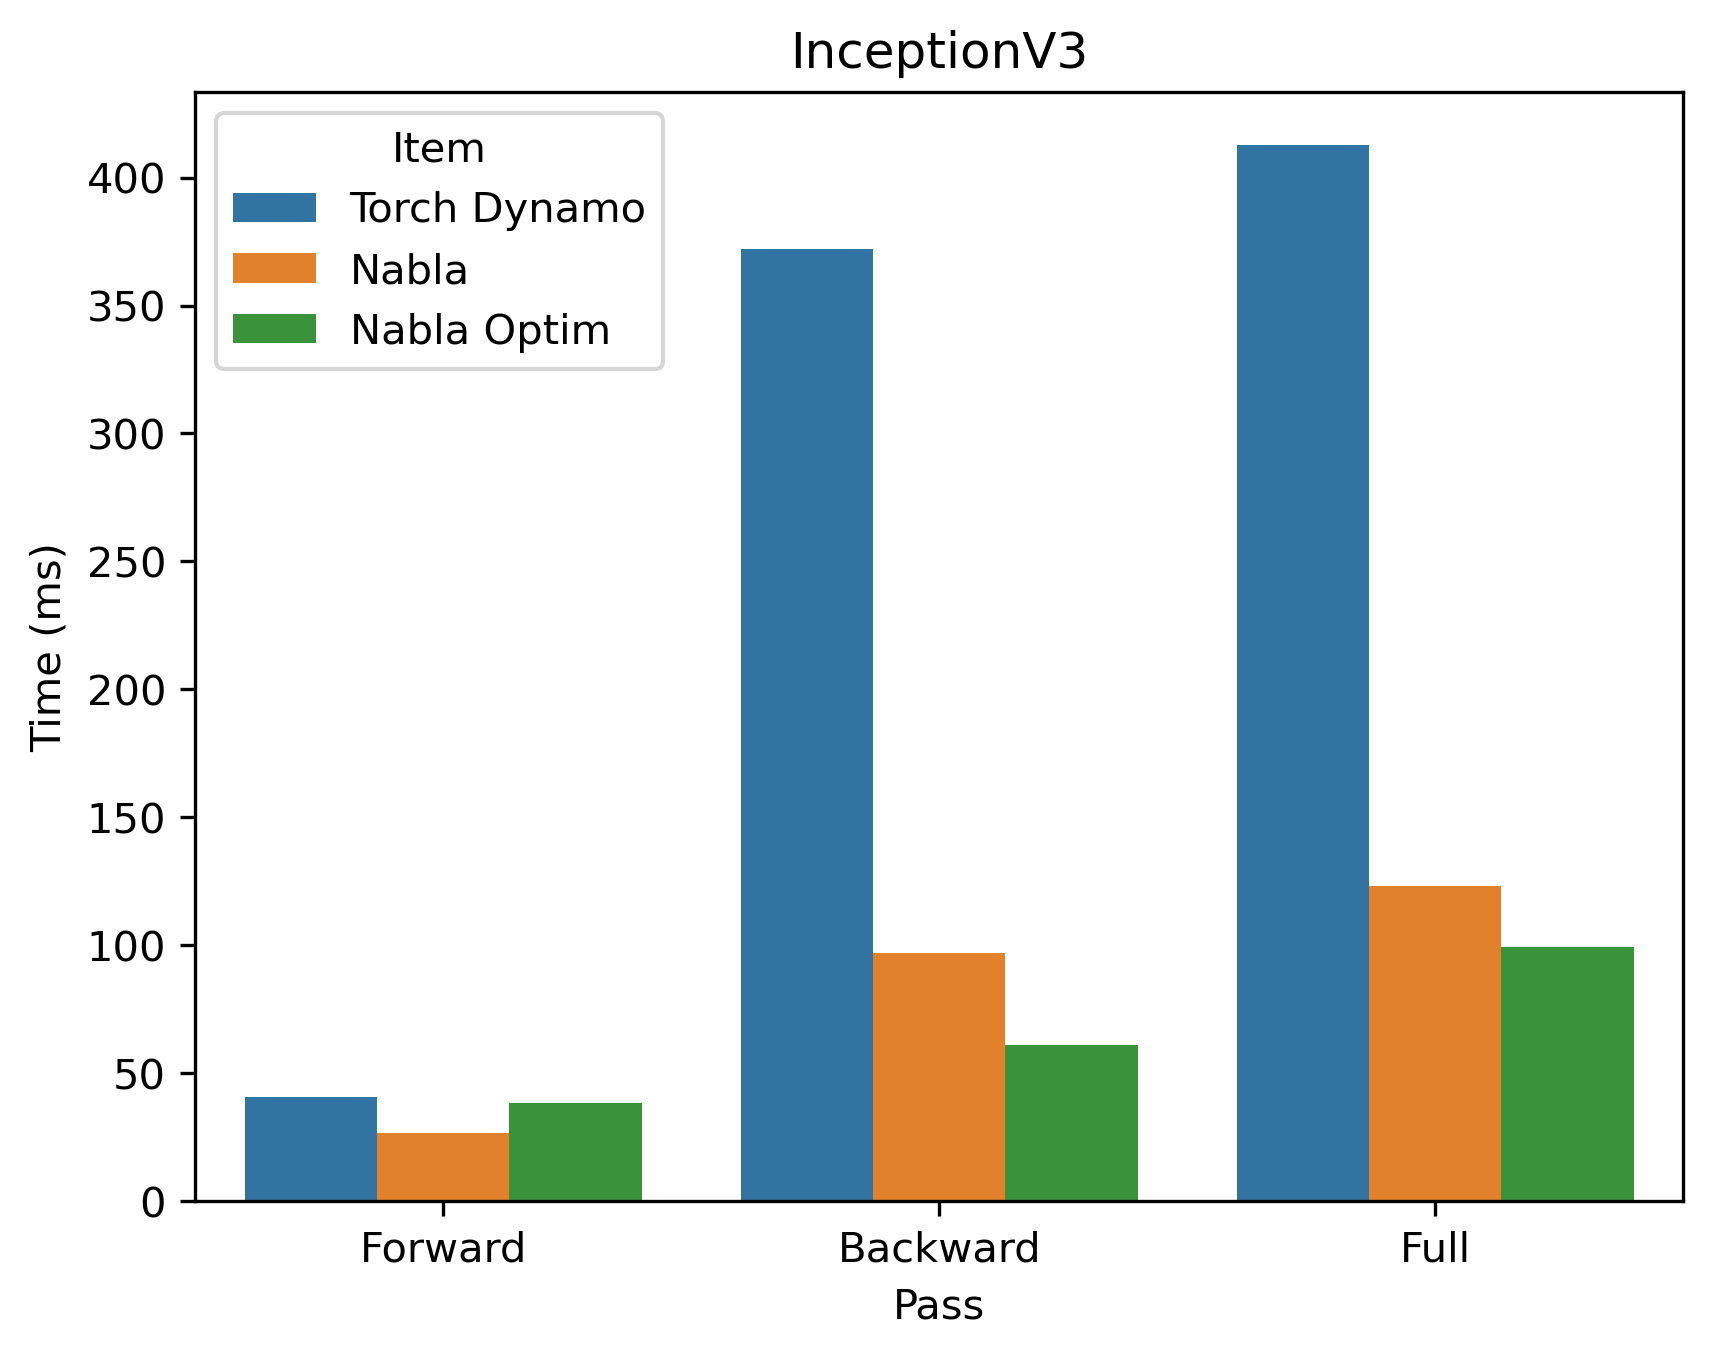

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,40.739383,Forward,Torch Dynamo,1.000000
0,26.511164,Forward,Nabla,1.536688
0,38.385541,Forward,Nabla Optim,1.061321


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,371.915455,Backward,Torch Dynamo,1.000000
0,96.804847,Backward,Nabla,3.841909
0,60.892456,Backward,Nabla Optim,6.107743


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,412.654837,Full,Torch Dynamo,1.000000
0,123.316012,Full,Nabla,3.346320
0,99.277997,Full,Nabla Optim,4.156559


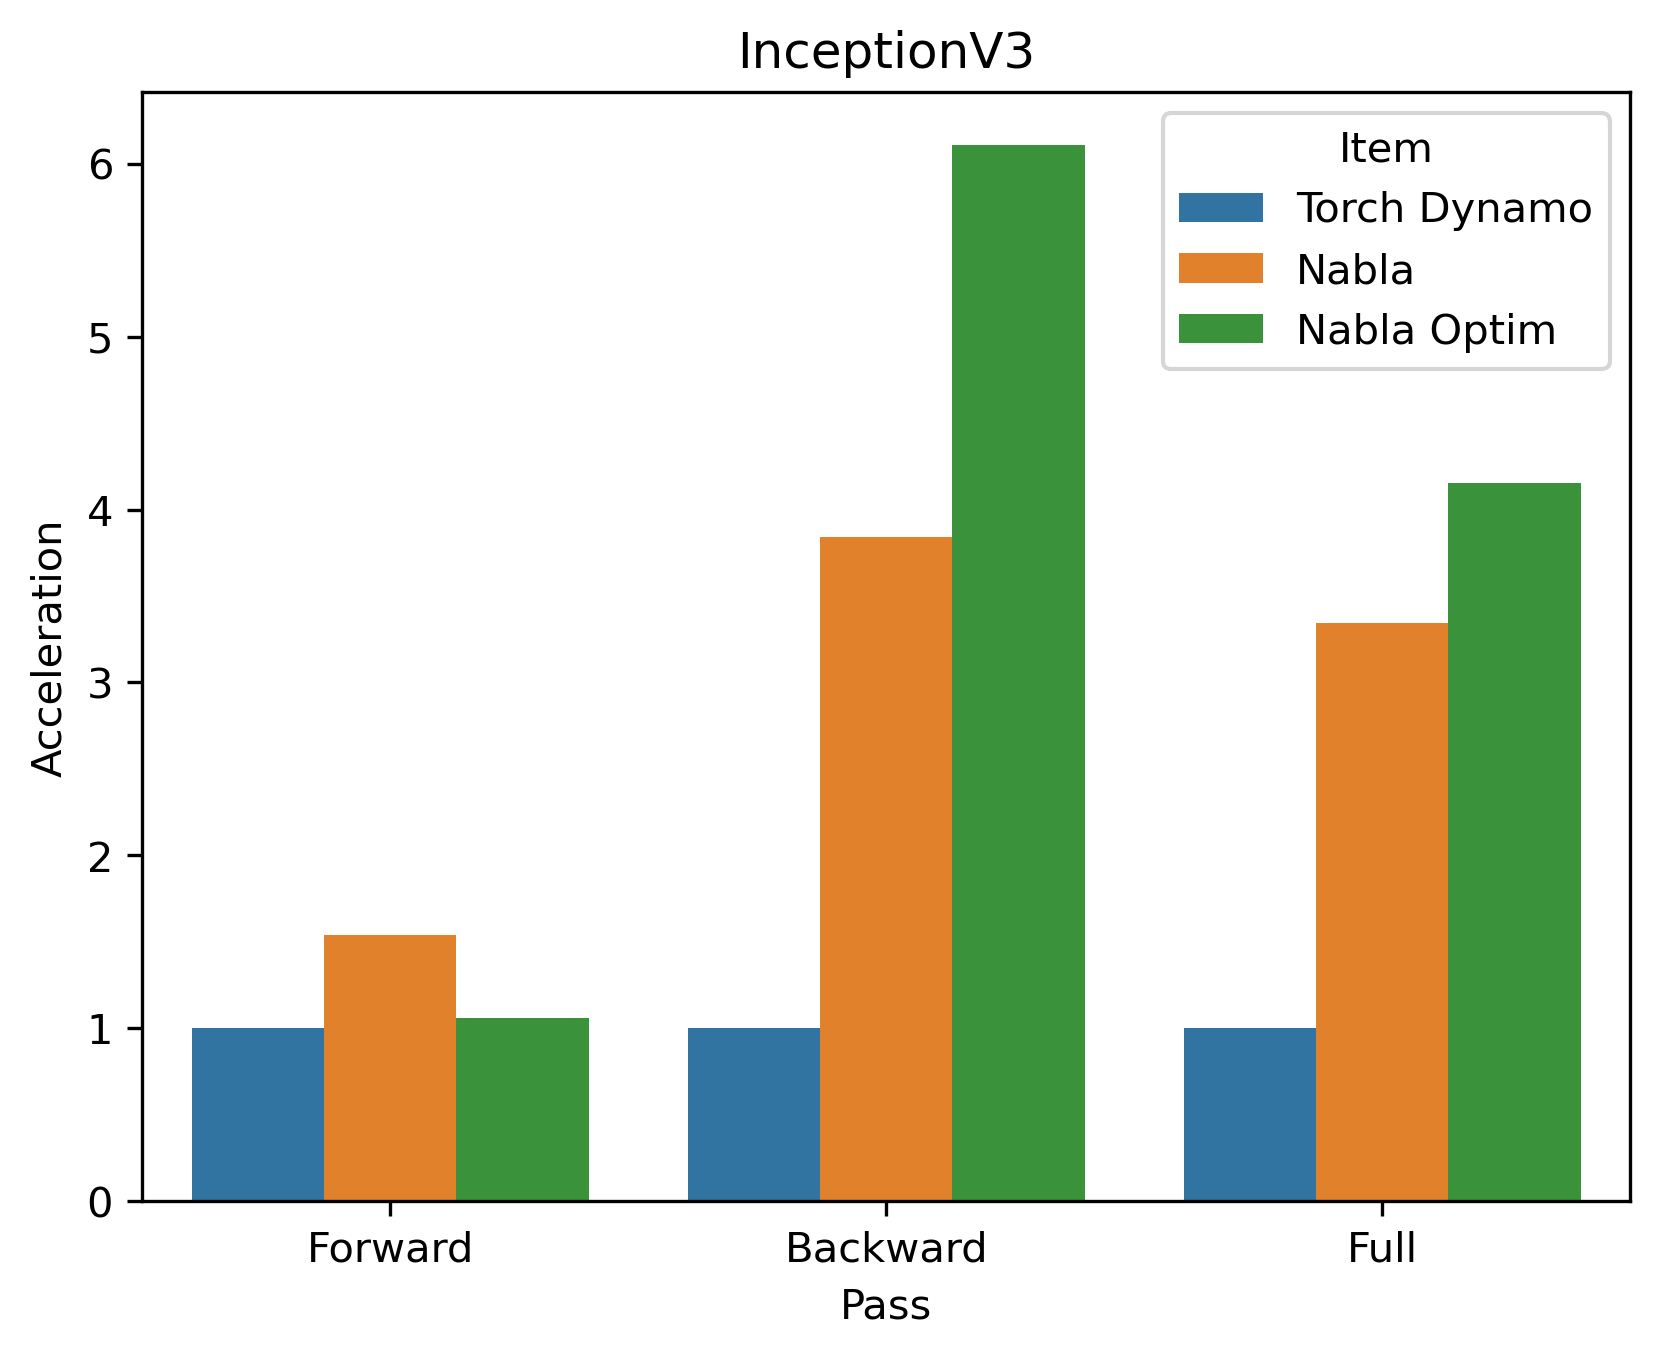

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")